In [ ]:
import marimo as mo
import numpy as np
import polars as pl
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl

# Mandat - 02: Statistiques descriptives et inférence statistique

In [ ]:
dataset = np.loadtxt("input/TempsDeJeu.txt")

In [ ]:
def hours(m):
    return m / 60


stats_dict = {
    "Moyenne": hours(dataset.mean()),
    "Mediane": hours(np.median(dataset)),
    "Mode": hours(stats.mode(dataset).mode.item()),
    "Ecart type": hours(np.std(dataset, ddof=1)),
    "Variance": hours(np.var(dataset, ddof=1)),
    "Min": hours(dataset.min()),
    "Max": hours(dataset.max()),
    "Etendue": hours(np.ptp(dataset)),
}

df = pl.DataFrame(
    {
        "Metrique": list(stats_dict.keys()),
        "Valeur": [round(v, 2) for v in stats_dict.values()],
    }
)

In [ ]:
mo.md(rf"""
# I) Statistiques descriptives des temps de jeu

{mo.ui.table(df, selection=None)}
""")

<span class="markdown prose dark:prose-invert contents"><h1 id="i-statistiques-descriptives-des-temps-de-jeu">I) Statistiques descriptives des temps de jeu</h1>
<span class="paragraph"><marimo-ui-element object-id='bkHC-0' random-id='4c2c6a2b-1783-41b7-38ed-3cf28a26d352'><marimo-table data-initial-value='[]' data-label='null' data-data='&quot;[{&#92;&quot;Metrique&#92;&quot;:&#92;&quot;Moyenne&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:4.68},{&#92;&quot;Metrique&#92;&quot;:&#92;&quot;Mediane&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:4.65},{&#92;&quot;Metrique&#92;&quot;:&#92;&quot;Mode&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:4.22},{&#92;&quot;Metrique&#92;&quot;:&#92;&quot;Ecart type&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:0.84},{&#92;&quot;Metrique&#92;&quot;:&#92;&quot;Variance&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:42.3},{&#92;&quot;Metrique&#92;&quot;:&#92;&quot;Min&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:2.47},{&#92;&quot;Metrique&#92;&quot;:&#92;&quot;Max&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:6.37},{&#92;&quot;Metrique&#92;&quot;:&#92;&quot;Etendue&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:3.9}]&quot;' data-total-rows='8' data-total-columns='2' data-max-columns='50' data-banner-text='&quot;&quot;' data-pagination='false' data-page-size='10' data-field-types='[[&quot;Metrique&quot;,[&quot;string&quot;,&quot;str&quot;]],[&quot;Valeur&quot;,[&quot;number&quot;,&quot;f64&quot;]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='&quot;df&quot;'></marimo-table></marimo-ui-element></span></span>

# II) Construction de l'histogramme des données

In [ ]:
k = int(np.ceil(1 + np.log2(len(dataset))))
min_val, max_val = dataset.min(), dataset.max()
amplitude = (max_val - min_val) / k

classes = []
limites = []
centres = []
frequences = []

for i in range(k):
    lower = min_val + i * amplitude
    upper = min_val + (i + 1) * amplitude
    centres.append((lower + upper) / 2)
    limites.append(f"[{lower:.0f}, {upper:.0f})")

    if i == k - 1:
        limites[-1] = f"[{lower:.0f}, {upper:.0f}]"

    count = np.sum(
        (dataset >= lower) & (dataset < upper)
        if i < k - 1
        else (dataset >= lower) & (dataset <= upper)
    )
    frequences.append(count)

freq_relatives = [f / len(dataset) for f in frequences]
freq_cumulees = np.cumsum(frequences).tolist()

classes_col = [f"Classe {i + 1}" for i in range(k)]

freq_df = pl.DataFrame(
    {
        "Classes": classes_col,
        "Limites": limites,
        "Centres": [round(c, 1) for c in centres],
        "Freq. relatives": [round(f, 4) for f in freq_relatives],
        "Freq. cumulees": freq_cumulees,
    }
)

In [ ]:
mo.md(rf"""
## Nombre de classes
La loi de Sturges est utilisée pour déterminer le nombre de classes:

$$
k = \lceil 1 + \log_2(n) \rceil = {k}
$$

Où:

| | |
|-|-|
| k | nombre de classes |
| n | taille de l'échantillon |

## Population du tableau de valeurs

{mo.ui.table(freq_df, selection=None)}
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="nombre-de-classes">Nombre de classes</h2>
<span class="paragraph">La loi de Sturges est utilisée pour déterminer le nombre de classes:</span>
$$
k = \lceil 1 + \log_2(n) \rceil = 8
$$<span class="paragraph">Où:</span>
<table>
<thead>
<tr>
<th></th>
<th></th>
</tr>
</thead>
<tbody>
<tr>
<td>k</td>
<td>nombre de classes</td>
</tr>
<tr>
<td>n</td>
<td>taille de l'échantillon</td>
</tr>
</tbody>
</table>
<h2 id="population-du-tableau-de-valeurs">Population du tableau de valeurs</h2>
<span class="paragraph"><marimo-ui-element object-id='Xref-0' random-id='af6ca389-a9ea-b690-8353-092eea54816c'><marimo-table data-initial-value='[]' data-label='null' data-data='&quot;[{&#92;&quot;Classes&#92;&quot;:&#92;&quot;Classe 1&#92;&quot;,&#92;&quot;Limites&#92;&quot;:&#92;&quot;[148, 177)&#92;&quot;,&#92;&quot;Centres&#92;&quot;:162.6,&#92;&quot;Freq. relatives&#92;&quot;:0.02,&#92;&quot;Freq. cumulees&#92;&quot;:2},{&#92;&quot;Classes&#92;&quot;:&#92;&quot;Classe 2&#92;&quot;,&#92;&quot;Limites&#92;&quot;:&#92;&quot;[177, 206)&#92;&quot;,&#92;&quot;Centres&#92;&quot;:191.9,&#92;&quot;Freq. relatives&#92;&quot;:0.04,&#92;&quot;Freq. cumulees&#92;&quot;:6},{&#92;&quot;Classes&#92;&quot;:&#92;&quot;Classe 3&#92;&quot;,&#92;&quot;Limites&#92;&quot;:&#92;&quot;[206, 236)&#92;&quot;,&#92;&quot;Centres&#92;&quot;:221.1,&#92;&quot;Freq. relatives&#92;&quot;:0.12,&#92;&quot;Freq. cumulees&#92;&quot;:18},{&#92;&quot;Classes&#92;&quot;:&#92;&quot;Classe 4&#92;&quot;,&#92;&quot;Limites&#92;&quot;:&#92;&quot;[236, 265)&#92;&quot;,&#92;&quot;Centres&#92;&quot;:250.4,&#92;&quot;Freq. relatives&#92;&quot;:0.19,&#92;&quot;Freq. cumulees&#92;&quot;:37},{&#92;&quot;Classes&#92;&quot;:&#92;&quot;Classe 5&#92;&quot;,&#92;&quot;Limites&#92;&quot;:&#92;&quot;[265, 294)&#92;&quot;,&#92;&quot;Centres&#92;&quot;:279.6,&#92;&quot;Freq. relatives&#92;&quot;:0.26,&#92;&quot;Freq. cumulees&#92;&quot;:63},{&#92;&quot;Classes&#92;&quot;:&#92;&quot;Classe 6&#92;&quot;,&#92;&quot;Limites&#92;&quot;:&#92;&quot;[294, 324)&#92;&quot;,&#92;&quot;Centres&#92;&quot;:308.9,&#92;&quot;Freq. relatives&#92;&quot;:0.17,&#92;&quot;Freq. cumulees&#92;&quot;:80},{&#92;&quot;Classes&#92;&quot;:&#92;&quot;Classe 7&#92;&quot;,&#92;&quot;Limites&#92;&quot;:&#92;&quot;[324, 353)&#92;&quot;,&#92;&quot;Centres&#92;&quot;:338.1,&#92;&quot;Freq. relatives&#92;&quot;:0.11,&#92;&quot;Freq. cumulees&#92;&quot;:91},{&#92;&quot;Classes&#92;&quot;:&#92;&quot;Classe 8&#92;&quot;,&#92;&quot;Limites&#92;&quot;:&#92;&quot;[353, 382]&#92;&quot;,&#92;&quot;Centres&#92;&quot;:367.4,&#92;&quot;Freq. relatives&#92;&quot;:0.09,&#92;&quot;Freq. cumulees&#92;&quot;:100}]&quot;' data-total-rows='8' data-total-columns='5' data-max-columns='50' data-banner-text='&quot;&quot;' data-pagination='false' data-page-size='10' data-field-types='[[&quot;Classes&quot;,[&quot;string&quot;,&quot;str&quot;]],[&quot;Limites&quot;,[&quot;string&quot;,&quot;str&quot;]],[&quot;Centres&quot;,[&quot;number&quot;,&quot;f64&quot;]],[&quot;Freq. relatives&quot;,[&quot;number&quot;,&quot;f64&quot;]],[&quot;Freq. cumulees&quot;,[&quot;integer&quot;,&quot;i64&quot;]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='&quot;freq_df&quot;'></marimo-table></marimo-ui-element></span></span>

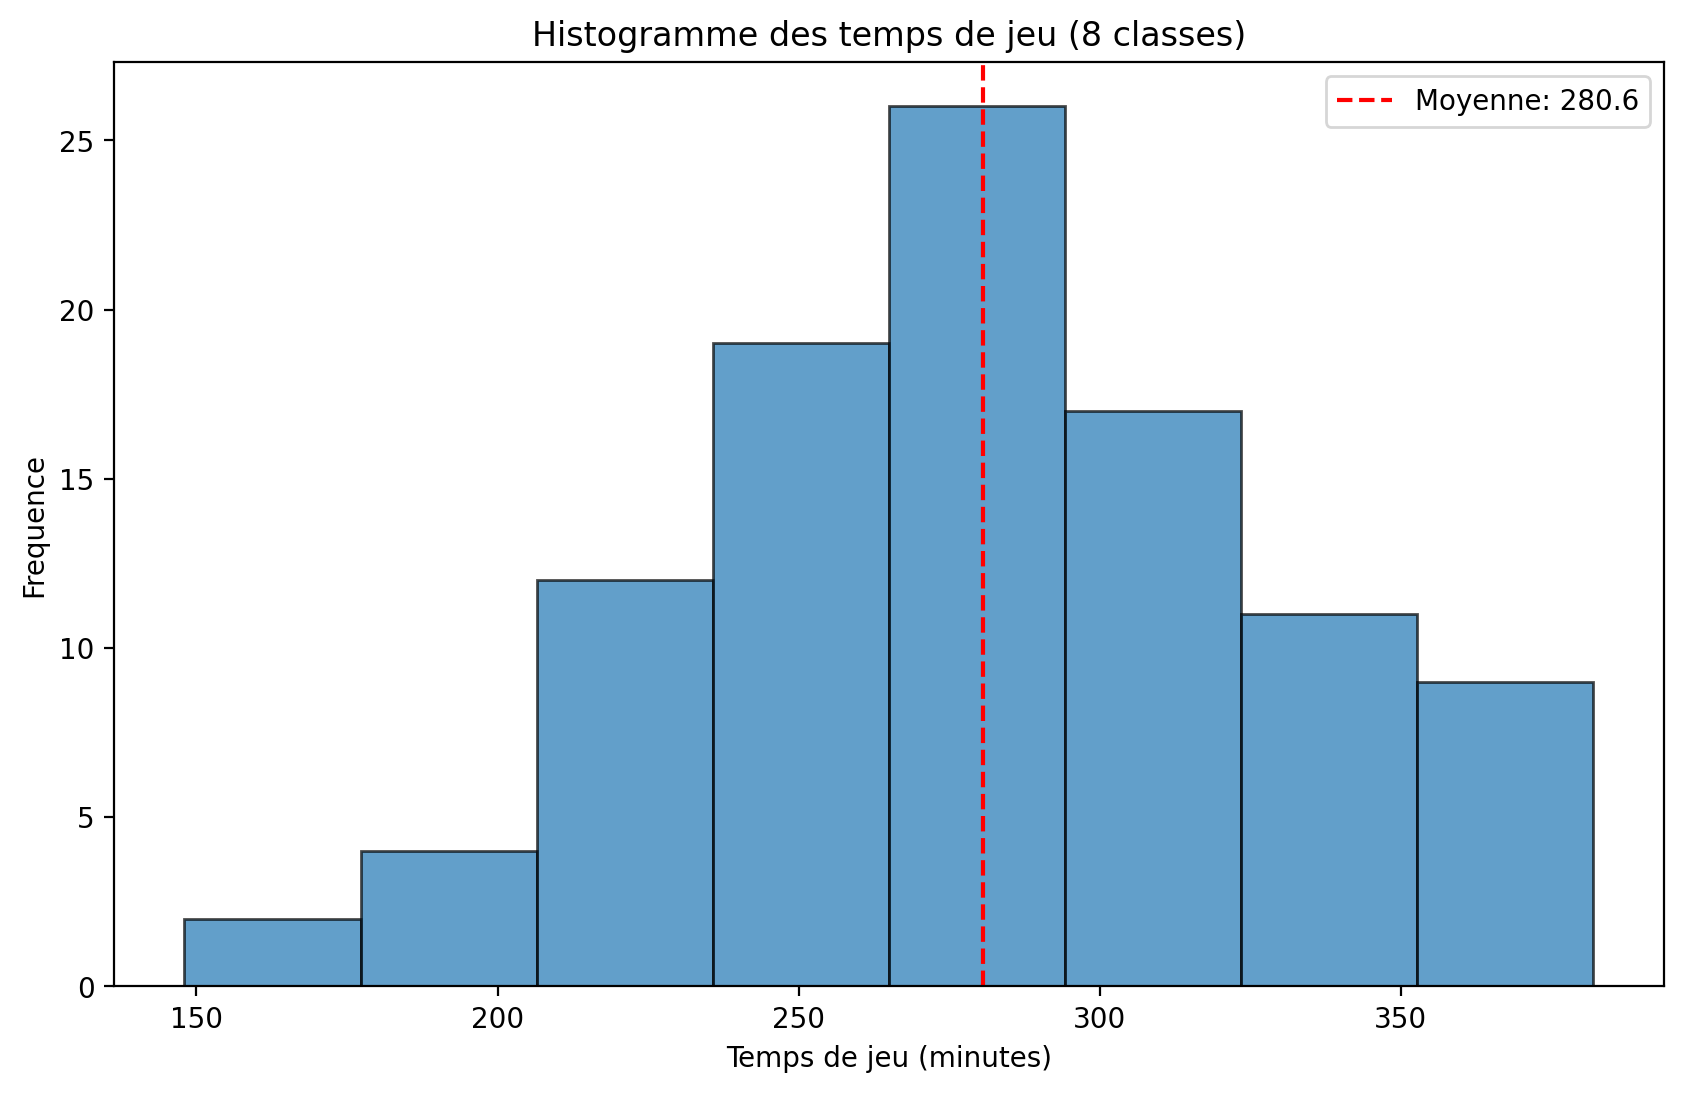

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(dataset, bins=k, edgecolor="black", alpha=0.7)
plt.xlabel("Temps de jeu (minutes)")
plt.ylabel("Frequence")
plt.title(f"Histogramme des temps de jeu ({k} classes)")
plt.axvline(
    dataset.mean(),
    color="red",
    linestyle="--",
    label=f"Moyenne: {dataset.mean():.1f}",
)
plt.legend()
plt.gca()

# III) Les données suivent-elles une distribution normale?

En observant l'histogramme ci-dessus, on peut voir que les données semblent suivre une distribution
approximativement normale (forme de cloche). Pour le confirmer quantitativement, nous utilisons le test de Khi-deux.

In [ ]:
_mean = dataset.mean()
_std = dataset.std(ddof=1)
_n = len(dataset)

_k_chi2 = int(np.ceil(1 + np.log2(_n)))
_min_val, _max_val = dataset.min(), dataset.max()
_amplitude = (_max_val - _min_val) / _k_chi2

_observed_freq = []
_expected_freq = []
_bins_edges = []

for _i in range(_k_chi2):
    _lower = _min_val + _i * _amplitude
    _upper = _min_val + (_i + 1) * _amplitude
    _bins_edges.append((_lower, _upper))

    _count_obs = np.sum(
        (dataset >= _lower) & (dataset < _upper)
        if _i < _k_chi2 - 1
        else (dataset >= _lower) & (dataset <= _upper)
    )
    _observed_freq.append(_count_obs)

    _prob_lower = stats.norm.cdf(_lower, loc=_mean, scale=_std)
    _prob_upper = stats.norm.cdf(_upper, loc=_mean, scale=_std)
    _prob_class = _prob_upper - _prob_lower
    _expected_freq.append(_n * _prob_class)

_observed_freq = np.array(_observed_freq)
_expected_freq = np.array(_expected_freq)

chi2_stat = np.sum((_observed_freq - _expected_freq) ** 2 / _expected_freq)

ddof_chi2 = _k_chi2 - 1 - 2
p_value = 1 - stats.chi2.cdf(chi2_stat, df=ddof_chi2)
# TODO: FAIRE L'AJUSTEMENT
alpha = 0.05
chi2_critical = stats.chi2.ppf(1 - alpha, df=ddof_chi2)

chi2_result_df = pl.DataFrame(
    {
        "Classe": [
            f"[{_lower:.0f}, {_upper:.0f}]" for _lower, _upper in _bins_edges
        ],
        "Freq. observee": _observed_freq.tolist(),
        "Freq. attendue": [round(_f, 2) for _f in _expected_freq],
    }
)

In [ ]:
reject_h0 = p_value < alpha
conclusion = "rejeter" if reject_h0 else "ne pas rejeter"

mo.md(rf"""
## Test de Khi-deux (test de Pearson)

**Hypothèses:**
- H₀: Les données suivent une distribution normale
- H₁: Les données ne suivent pas une distribution normale

**Résultats:**

{mo.ui.table(chi2_result_df, selection=None)}

**Statistiques du test:**

| Métrique | Valeur |
|----------|--------|
| Statistique χ² | {chi2_stat:.4f} |
| Degrés de liberté | {ddof_chi2} |
| Valeur p | {p_value:.4f} |
| Valeur critique (α={alpha}) | {chi2_critical:.4f} |

**Conclusion:**

Au seuil de signification α = {alpha}, on {"**rejette**" if reject_h0 else "**ne rejette pas**"} l'hypothèse nulle.

{"Les données **ne suivent pas** une distribution normale." if reject_h0 else "Les données **suivent** une distribution normale."}
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="test-de-khi-deux-test-de-pearson">Test de Khi-deux (test de Pearson)</h2>
<span class="paragraph"><strong>Hypothèses:</strong></span>
<ul>
<li>H₀: Les données suivent une distribution normale</li>
<li>H₁: Les données ne suivent pas une distribution normale</li>
</ul>
<span class="paragraph"><strong>Résultats:</strong></span>
<span class="paragraph"><marimo-ui-element object-id='Kclp-0' random-id='7190a656-f372-759e-81a2-e8175a6ce474'><marimo-table data-initial-value='[]' data-label='null' data-data='&quot;[{&#92;&quot;Classe&#92;&quot;:&#92;&quot;[148, 177]&#92;&quot;,&#92;&quot;Freq. observee&#92;&quot;:2,&#92;&quot;Freq. attendue&#92;&quot;:1.59},{&#92;&quot;Classe&#92;&quot;:&#92;&quot;[177, 206]&#92;&quot;,&#92;&quot;Freq. observee&#92;&quot;:4,&#92;&quot;Freq. attendue&#92;&quot;:5.06},{&#92;&quot;Classe&#92;&quot;:&#92;&quot;[206, 236]&#92;&quot;,&#92;&quot;Freq. observee&#92;&quot;:12,&#92;&quot;Freq. attendue&#92;&quot;:11.61},{&#92;&quot;Classe&#92;&quot;:&#92;&quot;[236, 265]&#92;&quot;,&#92;&quot;Freq. observee&#92;&quot;:19,&#92;&quot;Freq. attendue&#92;&quot;:19.18},{&#92;&quot;Classe&#92;&quot;:&#92;&quot;[265, 294]&#92;&quot;,&#92;&quot;Freq. observee&#92;&quot;:26,&#92;&quot;Freq. attendue&#92;&quot;:22.84},{&#92;&quot;Classe&#92;&quot;:&#92;&quot;[294, 324]&#92;&quot;,&#92;&quot;Freq. observee&#92;&quot;:17,&#92;&quot;Freq. attendue&#92;&quot;:19.59},{&#92;&quot;Classe&#92;&quot;:&#92;&quot;[324, 353]&#92;&quot;,&#92;&quot;Freq. observee&#92;&quot;:11,&#92;&quot;Freq. attendue&#92;&quot;:12.11},{&#92;&quot;Classe&#92;&quot;:&#92;&quot;[353, 382]&#92;&quot;,&#92;&quot;Freq. observee&#92;&quot;:9,&#92;&quot;Freq. attendue&#92;&quot;:5.39}]&quot;' data-total-rows='8' data-total-columns='3' data-max-columns='50' data-banner-text='&quot;&quot;' data-pagination='false' data-page-size='10' data-field-types='[[&quot;Classe&quot;,[&quot;string&quot;,&quot;str&quot;]],[&quot;Freq. observee&quot;,[&quot;integer&quot;,&quot;i64&quot;]],[&quot;Freq. attendue&quot;,[&quot;number&quot;,&quot;f64&quot;]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='&quot;chi2_result_df&quot;'></marimo-table></marimo-ui-element></span>
<span class="paragraph"><strong>Statistiques du test:</strong></span>
<table>
<thead>
<tr>
<th>Métrique</th>
<th>Valeur</th>
</tr>
</thead>
<tbody>
<tr>
<td>Statistique χ²</td>
<td>3.6376</td>
</tr>
<tr>
<td>Degrés de liberté</td>
<td>5</td>
</tr>
<tr>
<td>Valeur p</td>
<td>0.6027</td>
</tr>
<tr>
<td>Valeur critique (α=0.05)</td>
<td>11.0705</td>
</tr>
</tbody>
</table>
<span class="paragraph"><strong>Conclusion:</strong></span>
<span class="paragraph">Au seuil de signification α = 0.05, on <strong>ne rejette pas</strong> l'hypothèse nulle.</span>
<span class="paragraph">Les données <strong>suivent</strong> une distribution normale.</span></span>

# IV) Intervalle de confiance pour la moyenne

Calculez l'intervalle de confiance pour la moyenne des temps de jeu avec un niveau de
confiance de 95%. Vous ferez alors usage des tables de la distribution normale centrée réduite.

In [ ]:
confidence_level = 0.95
alpha_ci = 1 - confidence_level

sample_mean = dataset.mean()
sample_std = dataset.std(ddof=1)
n_samples = len(dataset)

z_critical = stats.norm.ppf(1 - alpha_ci / 2)

standard_error = sample_std / np.sqrt(n_samples)
margin_of_error = z_critical * standard_error

ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

ci_df = pl.DataFrame(
    {
        "Paramètre": [
            "Moyenne de l'échantillon (min)",
            "Moyenne de l'échantillon (h)",
            "Écart-type de l'échantillon (min)",
            "Taille de l'échantillon",
            "Niveau de confiance",
            "Valeur critique z",
            "Erreur standard (min)",
            "Marge d'erreur (min)",
            "Limite inférieure (min)",
            "Limite supérieure (min)",
            "Limite inférieure (h)",
            "Limite supérieure (h)",
        ],
        "Valeur": [
            f"{sample_mean:.2f}",
            f"{hours(sample_mean):.2f}",
            f"{sample_std:.2f}",
            f"{n_samples}",
            f"{confidence_level * 100:.0f}%",
            f"{z_critical:.4f}",
            f"{standard_error:.2f}",
            f"{margin_of_error:.2f}",
            f"{ci_lower:.2f}",
            f"{ci_upper:.2f}",
            f"{hours(ci_lower):.2f}",
            f"{hours(ci_upper):.2f}",
        ],
    }
)

In [ ]:
mo.md(rf"""
## Calcul de l'intervalle de confiance

Pour un niveau de confiance de {confidence_level * 100:.0f}%, l'intervalle de confiance pour la moyenne est calculé avec la formule:

$$
\bar{{x}} \pm z_{{\alpha/2}} \times \frac{{s}}{{\sqrt{{n}}}}
$$

Où:

| Symbole | Description |
|---------|-------------|
| $\bar{{x}}$ | Moyenne de l'échantillon |
| $z_{{\alpha/2}}$ | Valeur critique de la distribution normale (pour α={alpha_ci}) |
| $s$ | Écart-type de l'échantillon |
| $n$ | Taille de l'échantillon |

**Résultats:**

{mo.ui.table(ci_df, selection=None)}

**Conclusion:**

Avec un niveau de confiance de {confidence_level * 100:.0f}%, l'intervalle de confiance pour la moyenne des temps de jeu est:

$$
[{ci_lower:.2f}, {ci_upper:.2f}] \text{{ minutes}} = [{hours(ci_lower):.2f}, {hours(ci_upper):.2f}] \text{{ heures}}
$$

Cela signifie que nous sommes {confidence_level * 100:.0f}% confiants que la vraie moyenne de la population se situe dans cet intervalle.
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="calcul-de-lintervalle-de-confiance">Calcul de l'intervalle de confiance</h2>
<span class="paragraph">Pour un niveau de confiance de 95%, l'intervalle de confiance pour la moyenne est calculé avec la formule:</span>
$$
\bar{x} \pm z_{\alpha/2} \times \frac{s}{\sqrt{n}}
$$<span class="paragraph">Où:</span>
<table>
<thead>
<tr>
<th>Symbole</th>
<th>Description</th>
</tr>
</thead>
<tbody>
<tr>
<td>$\bar{x}$</td>
<td>Moyenne de l'échantillon</td>
</tr>
<tr>
<td>$z_{\alpha/2}$</td>
<td>Valeur critique de la distribution normale (pour α=0.050000000000000044)</td>
</tr>
<tr>
<td>$s$</td>
<td>Écart-type de l'échantillon</td>
</tr>
<tr>
<td>$n$</td>
<td>Taille de l'échantillon</td>
</tr>
</tbody>
</table>
<span class="paragraph"><strong>Résultats:</strong></span>
<span class="paragraph"><marimo-ui-element object-id='nWHF-0' random-id='d2c44254-19e2-ab3a-b3e3-65f6bceb1777'><marimo-table data-initial-value='[]' data-label='null' data-data='&quot;[{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Moyenne de l&#x27;&#92;&#92;u00e9chantillon (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;280.58&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Moyenne de l&#x27;&#92;&#92;u00e9chantillon (h)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;4.68&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;&#92;&#92;u00c9cart-type de l&#x27;&#92;&#92;u00e9chantillon (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;50.38&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Taille de l&#x27;&#92;&#92;u00e9chantillon&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;100&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Niveau de confiance&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;95%&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Valeur critique z&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;1.9600&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Erreur standard (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;5.04&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Marge d&#x27;erreur (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;9.87&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Limite inf&#92;&#92;u00e9rieure (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;270.71&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Limite sup&#92;&#92;u00e9rieure (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;290.45&#92;&quot;}]&quot;' data-total-rows='12' data-total-columns='2' data-max-columns='50' data-banner-text='&quot;&quot;' data-pagination='true' data-page-size='10' data-field-types='[[&quot;Paramètre&quot;,[&quot;string&quot;,&quot;str&quot;]],[&quot;Valeur&quot;,[&quot;string&quot;,&quot;str&quot;]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='&quot;ci_df&quot;'></marimo-table></marimo-ui-element></span>
<span class="paragraph"><strong>Conclusion:</strong></span>
<span class="paragraph">Avec un niveau de confiance de 95%, l'intervalle de confiance pour la moyenne des temps de jeu est:</span>
$$
[270.71, 290.45] \text{ minutes} = [4.51, 4.84] \text{ heures}
$$<span class="paragraph">Cela signifie que nous sommes 95% confiants que la vraie moyenne de la population se situe dans cet intervalle.</span></span>

# V) Test d'hypothèse sur la moyenne

Effectuez un test d'hypothèse approprié sur la moyenne afin d'évaluer si les données
fournissent suffisamment de preuves pour rejeter ou ne pas rejeter l'hypothèse de votre
patron énoncée précédemment. Considérez un niveau de confiance de 95%. Quelle est ici
l'erreur de première espèce?

In [ ]:
# Hypothesis test on the mean
# H0: μ ≥ 300 (boss claims average playtime is at least 300 minutes)
# H1: μ < 300 (one-tailed test, left-tailed)

mu_0 = 300  # hypothesized population mean (5 hours = 300 minutes)
alpha_v = 0.05  # significance level (95% confidence)

# Sample statistics
x_bar = dataset.mean()
s = dataset.std(ddof=1)
n = len(dataset)

# Test statistic (z-test since n is large)
z_stat = (x_bar - mu_0) / (s / np.sqrt(n))

# Critical value for one-tailed test (left-tailed)
z_critical_v = stats.norm.ppf(alpha_v)

# P-value for one-tailed test
p_value_v = stats.norm.cdf(z_stat)

# Decision
reject_h0_v = z_stat < z_critical_v

# Type I error (alpha) - probability of rejecting H0 when H0 is true
type_i_error = alpha_v

hyp_test_df = pl.DataFrame(
    {
        "Paramètre": [
            "Hypothèse nulle H₀",
            "Hypothèse alternative H₁",
            "Moyenne hypothétisée μ₀ (min)",
            "Moyenne hypothétisée μ₀ (h)",
            "Moyenne échantillonnale x̄ (min)",
            "Moyenne échantillonnale x̄ (h)",
            "Écart-type s (min)",
            "Taille de l'échantillon n",
            "Statistique de test z",
            "Valeur critique zα",
            "Valeur p",
            "Niveau de signification α",
            "Erreur de type I (α)",
        ],
        "Valeur": [
            "μ ≥ 300",
            "μ < 300",
            f"{mu_0}",
            f"{hours(mu_0):.2f}",
            f"{x_bar:.2f}",
            f"{hours(x_bar):.2f}",
            f"{s:.2f}",
            f"{n}",
            f"{z_stat:.4f}",
            f"{z_critical_v:.4f}",
            f"{p_value_v:.4f}",
            f"{alpha_v}",
            f"{type_i_error}",
        ],
    }
)

In [ ]:
mo.md(rf"""
## Test d'hypothèse unilatéral à gauche

**Formulation des hypothèses:**
- H₀: μ ≥ {mu_0} minutes ({hours(mu_0):.2f} heures) - L'hypothèse du patron
- H₁: μ < {mu_0} minutes - Le temps de jeu moyen est inférieur à 5 heures

**Méthode:** Test Z (n ≥ 30, distribution normale)

La statistique de test est:
$$
z = \frac{{\bar{{x}} - \mu_0}}{{s / \sqrt{{n}}}} = {z_stat:.4f}
$$

**Résultats:**

{mo.ui.table(hyp_test_df, selection=None)}

**Règle de décision:**

On rejette H₀ si z < z_α = {z_critical_v:.4f}

Puisque z = {z_stat:.4f} {"<" if z_stat < z_critical_v else "≥"} {z_critical_v:.4f}, on {"**rejette**" if reject_h0_v else "**ne rejette pas**"} H₀.

**Conclusion:**

Au niveau de signification α = {alpha_v}, {"les données fournissent suffisamment de preuves pour rejeter l'hypothèse du patron. Le temps de jeu moyen est significativement inférieur à 5 heures par semaine." if reject_h0_v else "les données ne fournissent pas suffisamment de preuves pour rejeter l'hypothèse du patron. On ne peut pas conclure que le temps de jeu moyen est inférieur à 5 heures par semaine."}

**Erreur de première espèce (α):**

L'erreur de type I est la probabilité de rejeter H₀ alors qu'elle est vraie. Ici, α = {type_i_error} = {type_i_error * 100}%.

Cela signifie qu'il y a {type_i_error * 100}% de chance de conclure à tort que le temps de jeu moyen est inférieur à 5 heures, alors qu'en réalité il est d'au moins 5 heures.
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="test-dhypothese-unilateral-a-gauche">Test d'hypothèse unilatéral à gauche</h2>
<span class="paragraph"><strong>Formulation des hypothèses:</strong></span>
<ul>
<li>H₀: μ ≥ 300 minutes (5.00 heures) - L'hypothèse du patron</li>
<li>H₁: μ &lt; 300 minutes - Le temps de jeu moyen est inférieur à 5 heures</li>
</ul>
<span class="paragraph"><strong>Méthode:</strong> Test Z (n ≥ 30, distribution normale)</span>
<span class="paragraph">La statistique de test est:</span>
$$
z = \frac{\bar{x} - \mu_0}{s / \sqrt{n}} = -3.8549
$$<span class="paragraph"><strong>Résultats:</strong></span>
<span class="paragraph"><marimo-ui-element object-id='ROlb-0' random-id='cfddd971-df06-6f2e-006b-d07e1e3865a3'><marimo-table data-initial-value='[]' data-label='null' data-data='&quot;[{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Hypoth&#92;&#92;u00e8se nulle H&#92;&#92;u2080&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;&#92;&#92;u03bc &#92;&#92;u2265 300&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Hypoth&#92;&#92;u00e8se alternative H&#92;&#92;u2081&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;&#92;&#92;u03bc &lt; 300&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Moyenne hypoth&#92;&#92;u00e9tis&#92;&#92;u00e9e &#92;&#92;u03bc&#92;&#92;u2080 (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;300&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Moyenne hypoth&#92;&#92;u00e9tis&#92;&#92;u00e9e &#92;&#92;u03bc&#92;&#92;u2080 (h)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;5.00&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Moyenne &#92;&#92;u00e9chantillonnale x&#92;&#92;u0304 (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;280.58&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Moyenne &#92;&#92;u00e9chantillonnale x&#92;&#92;u0304 (h)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;4.68&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;&#92;&#92;u00c9cart-type s (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;50.38&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Taille de l&#x27;&#92;&#92;u00e9chantillon n&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;100&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Statistique de test z&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;-3.8549&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Valeur critique z&#92;&#92;u03b1&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;-1.6449&#92;&quot;}]&quot;' data-total-rows='13' data-total-columns='2' data-max-columns='50' data-banner-text='&quot;&quot;' data-pagination='true' data-page-size='10' data-field-types='[[&quot;Paramètre&quot;,[&quot;string&quot;,&quot;str&quot;]],[&quot;Valeur&quot;,[&quot;string&quot;,&quot;str&quot;]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='&quot;hyp_test_df&quot;'></marimo-table></marimo-ui-element></span>
<span class="paragraph"><strong>Règle de décision:</strong></span>
<span class="paragraph">On rejette H₀ si z &lt; z_α = -1.6449</span>
<span class="paragraph">Puisque z = -3.8549 &lt; -1.6449, on <strong>rejette</strong> H₀.</span>
<span class="paragraph"><strong>Conclusion:</strong></span>
<span class="paragraph">Au niveau de signification α = 0.05, les données fournissent suffisamment de preuves pour rejeter l'hypothèse du patron. Le temps de jeu moyen est significativement inférieur à 5 heures par semaine.</span>
<span class="paragraph"><strong>Erreur de première espèce (α):</strong></span>
<span class="paragraph">L'erreur de type I est la probabilité de rejeter H₀ alors qu'elle est vraie. Ici, α = 0.05 = 5.0%.</span>
<span class="paragraph">Cela signifie qu'il y a 5.0% de chance de conclure à tort que le temps de jeu moyen est inférieur à 5 heures, alors qu'en réalité il est d'au moins 5 heures.</span></span>

# VI) Erreur de deuxième espèce

Supposons que la moyenne échantillonnale est un très bon estimé de la moyenne de la
population et qu'elle peut être considérée comme étant cette dernière, quelle est l'erreur de
deuxième espèce commise au point précédent si on ne rejette pas l'hypothèse nulle?

In [ ]:
# Type II error (β) calculation
# β = P(not rejecting H0 | H1 is true)
# Assuming the true population mean is equal to the sample mean (x_bar)

# True population mean (assumed to be the sample mean)
mu_true = x_bar

# Standard error
se = s / np.sqrt(n)

# Critical value for the test (x_c such that we reject H0 if x̄ < x_c)
# From z_α = (x_c - μ₀) / se, we get x_c = μ₀ + z_α * se
z_alpha = stats.norm.ppf(alpha_v)
x_critical = mu_0 + z_alpha * se

# Type II error: P(x̄ ≥ x_c | μ = μ_true)
# β = P(Z ≥ (x_c - μ_true) / se)
z_beta = (x_critical - mu_true) / se
beta = 1 - stats.norm.cdf(z_beta)

# Power of the test
power = 1 - beta

type_ii_df = pl.DataFrame(
    {
        "Paramètre": [
            "Vraie moyenne de la population μ (min)",
            "Moyenne hypothétisée μ₀ (min)",
            "Erreur standard",
            "Valeur critique x_c (min)",
            "z_β",
            "Erreur de type II (β)",
            "Puissance du test (1 - β)",
        ],
        "Valeur": [
            f"{mu_true:.2f}",
            f"{mu_0}",
            f"{se:.4f}",
            f"{x_critical:.2f}",
            f"{z_beta:.4f}",
            f"{beta:.4f}",
            f"{power:.4f}",
        ],
    }
)

In [ ]:
mo.md(rf"""
## Calcul de l'erreur de deuxième espèce (β)

L'erreur de type II (β) est la probabilité de ne pas rejeter H₀ alors que H₁ est vraie.

**Hypothèses:**
- On suppose que la vraie moyenne de la population est μ = x̄ = {mu_true:.2f} minutes ({hours(mu_true):.2f} heures)
- H₀: μ ≥ {mu_0} minutes
- H₁: μ < {mu_0} minutes

**Calcul:**

1. La valeur critique x_c est déterminée par:
$$
x_c = \mu_0 + z_\alpha \times SE = {mu_0} + {stats.norm.ppf(alpha_v):.4f} \times {se:.4f} = {x_critical:.2f}
$$

2. L'erreur de type II est:
$$
\beta = P(\bar{{X}} \geq x_c | \mu = \mu_{{vrai}}) = P\left(Z \geq \frac{{x_c - \mu_{{vrai}}}}{{SE}}\right) = P(Z \geq {z_beta:.4f}) = {beta:.4f}
$$

**Résultats:**

{mo.ui.table(type_ii_df, selection=None)}

**Interprétation:**

- L'erreur de type II (β) = {beta:.4f} = {beta * 100:.2f}%
- Cela signifie qu'il y a {beta * 100:.2f}% de chance de ne pas rejeter l'hypothèse du patron (μ ≥ 300 min) alors qu'en réalité la vraie moyenne est de {mu_true:.2f} minutes.
- La puissance du test (1 - β) = {power:.4f} = {power * 100:.2f}%
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="calcul-de-lerreur-de-deuxieme-espece">Calcul de l'erreur de deuxième espèce (β)</h2>
<span class="paragraph">L'erreur de type II (β) est la probabilité de ne pas rejeter H₀ alors que H₁ est vraie.</span>
<span class="paragraph"><strong>Hypothèses:</strong></span>
<ul>
<li>On suppose que la vraie moyenne de la population est μ = x̄ = 280.58 minutes (4.68 heures)</li>
<li>H₀: μ ≥ 300 minutes</li>
<li>H₁: μ &lt; 300 minutes</li>
</ul>
<span class="paragraph"><strong>Calcul:</strong></span>
<ol>
<li>La valeur critique x_c est déterminée par:</li>
</ol>
$$
x_c = \mu_0 + z_\alpha \times SE = 300 + -1.6449 \times 5.0377 = 291.71
$$<ol start="2">
<li>L'erreur de type II est:</li>
</ol>
$$
\beta = P(\bar{X} \geq x_c | \mu = \mu_{vrai}) = P\left(Z \geq \frac{x_c - \mu_{vrai}}{SE}\right) = P(Z \geq 2.2101) = 0.0135
$$<span class="paragraph"><strong>Résultats:</strong></span>
<span class="paragraph"><marimo-ui-element object-id='Vxnm-0' random-id='525ed955-f7eb-2e8a-d556-e30010c57e05'><marimo-table data-initial-value='[]' data-label='null' data-data='&quot;[{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Vraie moyenne de la population &#92;&#92;u03bc (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;280.58&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Moyenne hypoth&#92;&#92;u00e9tis&#92;&#92;u00e9e &#92;&#92;u03bc&#92;&#92;u2080 (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;300&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Erreur standard&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;5.0377&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Valeur critique x_c (min)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;291.71&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;z_&#92;&#92;u03b2&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;2.2101&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Erreur de type II (&#92;&#92;u03b2)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;0.0135&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Puissance du test (1 - &#92;&#92;u03b2)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;0.9865&#92;&quot;}]&quot;' data-total-rows='7' data-total-columns='2' data-max-columns='50' data-banner-text='&quot;&quot;' data-pagination='false' data-page-size='10' data-field-types='[[&quot;Paramètre&quot;,[&quot;string&quot;,&quot;str&quot;]],[&quot;Valeur&quot;,[&quot;string&quot;,&quot;str&quot;]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='&quot;type_ii_df&quot;'></marimo-table></marimo-ui-element></span>
<span class="paragraph"><strong>Interprétation:</strong></span>
<ul>
<li>L'erreur de type II (β) = 0.0135 = 1.35%</li>
<li>Cela signifie qu'il y a 1.35% de chance de ne pas rejeter l'hypothèse du patron (μ ≥ 300 min) alors qu'en réalité la vraie moyenne est de 280.58 minutes.</li>
<li>La puissance du test (1 - β) = 0.9865 = 98.65%</li>
</ul></span>

# VII) Test d'hypothèse bilatéral sur la variance

En supposant que l'écart-type des temps de jeu est de 50, effectuez un test d'hypothèse
bilatéral sur la variance avec un seuil de signification de 5% afin d'évaluer si les données
fournissent suffisamment de preuves pour rejeter ou ne pas rejeter l'hypothèse nulle.

In [ ]:
# Bilateral hypothesis test on variance
# H0: σ² = 50² = 2500 (population variance equals hypothesized value)
# H1: σ² ≠ 2500 (population variance is different)

sigma_0 = 50  # hypothesized population standard deviation
sigma_0_squared = sigma_0**2  # hypothesized population variance
alpha_vii = 0.05  # significance level

# Sample statistics
n_vii = len(dataset)
s_squared_vii = dataset.var(ddof=1)  # sample variance (unbiased)
s_vii = dataset.std(ddof=1)  # sample standard deviation

# Test statistic: Chi-square
# χ² = (n-1) * s² / σ₀²
chi2_stat_vii = (n_vii - 1) * s_squared_vii / sigma_0_squared

# Degrees of freedom
df_vii = n_vii - 1

# Critical values for two-tailed test
chi2_lower = stats.chi2.ppf(alpha_vii / 2, df=df_vii)
chi2_upper = stats.chi2.ppf(1 - alpha_vii / 2, df=df_vii)

# P-value for two-tailed test
# P-value = 2 * min(P(χ² < χ²_stat), P(χ² > χ²_stat))
p_lower = stats.chi2.cdf(chi2_stat_vii, df=df_vii)
p_upper = 1 - p_lower
p_value_vii = 2 * min(p_lower, p_upper)

# Decision
reject_h0_vii = chi2_stat_vii < chi2_lower or chi2_stat_vii > chi2_upper

variance_test_df = pl.DataFrame(
    {
        "Paramètre": [
            "Hypothèse nulle H₀",
            "Hypothèse alternative H₁",
            "Écart-type hypothétisé σ₀",
            "Variance hypothétisée σ₀²",
            "Taille de l'échantillon n",
            "Écart-type de l'échantillon s",
            "Variance de l'échantillon s²",
            "Degrés de liberté (n-1)",
            "Statistique χ²",
            "Valeur critique inférieure χ²_α/2",
            "Valeur critique supérieure χ²_1-α/2",
            "Valeur p",
            "Niveau de signification α",
        ],
        "Valeur": [
            "σ² = 2500",
            "σ² ≠ 2500",
            f"{sigma_0}",
            f"{sigma_0_squared}",
            f"{n_vii}",
            f"{s_vii:.2f}",
            f"{s_squared_vii:.2f}",
            f"{df_vii}",
            f"{chi2_stat_vii:.4f}",
            f"{chi2_lower:.4f}",
            f"{chi2_upper:.4f}",
            f"{p_value_vii:.4f}",
            f"{alpha_vii}",
        ],
    }
)

In [ ]:
mo.md(rf"""
## Test bilatéral sur la variance (test du Chi-deux)

**Formulation des hypothèses:**
- H₀: σ² = {sigma_0_squared} (σ = {sigma_0})
- H₁: σ² ≠ {sigma_0_squared}

**Méthode:** Test du Chi-deux pour la variance

La statistique de test est:
$$
\chi^2 = \frac{{(n-1) \cdot s^2}}{{\sigma_0^2}} = \frac{{{df_vii} \cdot {s_squared_vii:.2f}}}{{{sigma_0_squared}}} = {chi2_stat_vii:.4f}
$$

**Résultats:**

{mo.ui.table(variance_test_df, selection=None)}

**Règle de décision:**

On rejette H₀ si χ² < χ²_α/2 = {chi2_lower:.4f} ou χ² > χ²_1-α/2 = {chi2_upper:.4f}

Puisque χ² = {chi2_stat_vii:.4f} {"est dans la région de rejet" if reject_h0_vii else "n'est pas dans la région de rejet"} [{chi2_lower:.4f}, {chi2_upper:.4f}], on {"**rejette**" if reject_h0_vii else "**ne rejette pas**"} H₀.

**Conclusion:**

Au niveau de signification α = {alpha_vii}, {"les données fournissent suffisamment de preuves pour rejeter l'hypothèse que l'écart-type de la population est de 50 minutes. La variance de la population est significativement différente de 2500." if reject_h0_vii else "les données ne fournissent pas suffisamment de preuves pour rejeter l'hypothèse nulle. On ne peut pas conclure que la variance de la population est différente de 2500."}
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="test-bilateral-sur-la-variance-test-du-chi-deux">Test bilatéral sur la variance (test du Chi-deux)</h2>
<span class="paragraph"><strong>Formulation des hypothèses:</strong></span>
<ul>
<li>H₀: σ² = 2500 (σ = 50)</li>
<li>H₁: σ² ≠ 2500</li>
</ul>
<span class="paragraph"><strong>Méthode:</strong> Test du Chi-deux pour la variance</span>
<span class="paragraph">La statistique de test est:</span>
$$
\chi^2 = \frac{(n-1) \cdot s^2}{\sigma_0^2} = \frac{99 \cdot 2537.84}{2500} = 100.4985
$$<span class="paragraph"><strong>Résultats:</strong></span>
<span class="paragraph"><marimo-ui-element object-id='ecfG-0' random-id='187e5b59-3203-5106-2c47-70e20c80604c'><marimo-table data-initial-value='[]' data-label='null' data-data='&quot;[{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Hypoth&#92;&#92;u00e8se nulle H&#92;&#92;u2080&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;&#92;&#92;u03c3&#92;&#92;u00b2 = 2500&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Hypoth&#92;&#92;u00e8se alternative H&#92;&#92;u2081&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;&#92;&#92;u03c3&#92;&#92;u00b2 &#92;&#92;u2260 2500&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;&#92;&#92;u00c9cart-type hypoth&#92;&#92;u00e9tis&#92;&#92;u00e9 &#92;&#92;u03c3&#92;&#92;u2080&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;50&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Variance hypoth&#92;&#92;u00e9tis&#92;&#92;u00e9e &#92;&#92;u03c3&#92;&#92;u2080&#92;&#92;u00b2&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;2500&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Taille de l&#x27;&#92;&#92;u00e9chantillon n&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;100&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;&#92;&#92;u00c9cart-type de l&#x27;&#92;&#92;u00e9chantillon s&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;50.38&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Variance de l&#x27;&#92;&#92;u00e9chantillon s&#92;&#92;u00b2&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;2537.84&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Degr&#92;&#92;u00e9s de libert&#92;&#92;u00e9 (n-1)&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;99&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Statistique &#92;&#92;u03c7&#92;&#92;u00b2&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;100.4985&#92;&quot;},{&#92;&quot;Param&#92;&#92;u00e8tre&#92;&quot;:&#92;&quot;Valeur critique inf&#92;&#92;u00e9rieure &#92;&#92;u03c7&#92;&#92;u00b2_&#92;&#92;u03b1/2&#92;&quot;,&#92;&quot;Valeur&#92;&quot;:&#92;&quot;73.3611&#92;&quot;}]&quot;' data-total-rows='13' data-total-columns='2' data-max-columns='50' data-banner-text='&quot;&quot;' data-pagination='true' data-page-size='10' data-field-types='[[&quot;Paramètre&quot;,[&quot;string&quot;,&quot;str&quot;]],[&quot;Valeur&quot;,[&quot;string&quot;,&quot;str&quot;]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='true' data-show-data-types='true' data-show-page-size-selector='true' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[]' data-has-stable-row-id='false' data-lazy='false' data-preload='false' data-download-file-name='&quot;variance_test_df&quot;'></marimo-table></marimo-ui-element></span>
<span class="paragraph"><strong>Règle de décision:</strong></span>
<span class="paragraph">On rejette H₀ si χ² &lt; χ²_α/2 = 73.3611 ou χ² &gt; χ²_1-α/2 = 128.4220</span>
<span class="paragraph">Puisque χ² = 100.4985 n'est pas dans la région de rejet [73.3611, 128.4220], on <strong>ne rejette pas</strong> H₀.</span>
<span class="paragraph"><strong>Conclusion:</strong></span>
<span class="paragraph">Au niveau de signification α = 0.05, les données ne fournissent pas suffisamment de preuves pour rejeter l'hypothèse nulle. On ne peut pas conclure que la variance de la population est différente de 2500.</span></span>

# Extra) Variable aléatoire Q du temps de jeu

On définit ici la variable aléatoire Q représentant le temps de jeu d'un joueur.

In [ ]:
mu_q = dataset.mean()
sigma_q = dataset.std(ddof=1)

In [ ]:
mo.md(rf"""
## Définition de la variable aléatoire Q

Soit **Q** la variable aléatoire représentant le temps de jeu hebdomadaire d'un joueur (en minutes).

En supposant que les temps de jeu suivent une distribution normale, on a :

$$Q \sim \mathcal{{N}}(\mu, \sigma^2)$$

Où :

| Paramètre | Description | Valeur (min.) |
|-----------|-------------|--------------|
| $\mu$ | Moyenne | {mu_q:.2f} |
| $\sigma$ | Écart-type | {sigma_q:.2f} |
| $\sigma^2$ | Variance | {sigma_q**2:.2f} |

Thus, the probability density function of Q is:

$$f_Q(q) = \frac{{1}}{{\sigma\sqrt{{2\pi}}}} \exp\left(-\frac{{(q-\mu)^2}}{{2\sigma^2}}\right) = \frac{{1}}{{{sigma_q:.2f}\sqrt{{2\pi}}}} \exp\left(-\frac{{(q-{mu_q:.2f})^2}}{{2 \times {sigma_q**2:.2f}}}\right)$$
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="definition-de-la-variable-aleatoire-q">Définition de la variable aléatoire Q</h2>
<span class="paragraph">Soit <strong>Q</strong> la variable aléatoire représentant le temps de jeu hebdomadaire d'un joueur (en minutes).</span>
<span class="paragraph">En supposant que les temps de jeu suivent une distribution normale, on a :</span>
$$Q \sim \mathcal{N}(\mu, \sigma^2)$$<span class="paragraph">Où :</span>
<table>
<thead>
<tr>
<th>Paramètre</th>
<th>Description</th>
<th>Valeur (min.)</th>
</tr>
</thead>
<tbody>
<tr>
<td>$\mu$</td>
<td>Moyenne</td>
<td>280.58</td>
</tr>
<tr>
<td>$\sigma$</td>
<td>Écart-type</td>
<td>50.38</td>
</tr>
<tr>
<td>$\sigma^2$</td>
<td>Variance</td>
<td>2537.84</td>
</tr>
</tbody>
</table>
<span class="paragraph">Thus, the probability density function of Q is:</span>
$$f_Q(q) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(q-\mu)^2}{2\sigma^2}\right) = \frac{1}{50.38\sqrt{2\pi}} \exp\left(-\frac{(q-280.58)^2}{2 \times 2537.84}\right)$$</span>